In [1]:
import numpy as np
import pandas as pd
import joblib
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV,train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.metrics import  accuracy_score, precision_score,recall_score, f1_score,confusion_matrix,classification_report


In [2]:
df=pd.read_csv("Loan Dataset.csv")
df

,Applicant_ID,Gender,Age,Marital_Status,Dependents,Education,Employment_Status,Occupation_Type,Residential_Status,City/Town,...,Loan_Amount_Requested,Loan_Term,Loan_Purpose,Interest_Rate,Loan_Type,Co-Applicant,Bank_Account_History,Transaction_Frequency,Default_Risk,Loan_Approval_Status
0,1,Female,25,Married,2,Graduate,Employed,Business,Own,Urban,...,24535,209,Home,4.27,Secured,Yes,8,20,0.81,1
1,2,Male,36,Married,2,High School,Employed,Business,Own,Suburban,...,8288,33,Home,14.78,Unsecured,Yes,9,9,0.17,0
2,3,Male,43,Single,0,Postgraduate,Self-Employed,Freelancer,Own,Urban,...,10308,159,Vehicle,12.33,Secured,Yes,7,27,0.25,0
3,4,Female,28,Married,0,High School,Self-Employed,Freelancer,Rent,Suburban,...,33937,39,Personal,8.77,Secured,No,9,16,0.27,1
4,5,Female,32,Single,0,Graduate,Employed,Salaried,Rent,Suburban,...,23360,34,Home,9.04,Unsecured,No,1,17,0.32,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51995,51996,Female,47,Divorced,1,High School,Self-Employed,Professional,Own,Urban,...,15723,60,Home,12.52,Secured,Yes,2,26,0.61,1
51996,51997,Male,25,Married,3,High School,Self-Employed,Freelancer,Rent,Urban,...,21209,237,Vehicle,5.21,Unsecured,No,8,26,0.04,1
51997,51998,Female,48,Married,0,High School,Unemployed,Business,Rent,Urban,...,10540,60,Education,10.60,Unsecured,No,8,24,0.31,0
51998,51999,Female,48,Divorced,1,High School,Employed,Business,Own,Urban,...,16765,32,Vehicle,8.11,Secured,Yes,3,12,0.34,0


In [3]:
df.shape

(52000, 27)

In [4]:
df.dtypes

Applicant_ID                    int64
Gender                            str
Age                             int64
Marital_Status                    str
Dependents                      int64
Education                         str
Employment_Status                 str
Occupation_Type                   str
Residential_Status                str
City/Town                         str
Annual_Income                   int64
Monthly_Expenses                int64
Credit_Score                    int64
Existing_Loans                  int64
Total_Existing_Loan_Amount      int64
Outstanding_Debt                int64
Loan_History                    int64
Loan_Amount_Requested           int64
Loan_Term                       int64
Loan_Purpose                      str
Interest_Rate                 float64
Loan_Type                         str
Co-Applicant                      str
Bank_Account_History            int64
Transaction_Frequency           int64
Default_Risk                  float64
Loan_Approva

In [5]:
df.head()

,Applicant_ID,Gender,Age,Marital_Status,Dependents,Education,Employment_Status,Occupation_Type,Residential_Status,City/Town,...,Loan_Amount_Requested,Loan_Term,Loan_Purpose,Interest_Rate,Loan_Type,Co-Applicant,Bank_Account_History,Transaction_Frequency,Default_Risk,Loan_Approval_Status
0,1,Female,25,Married,2,Graduate,Employed,Business,Own,Urban,...,24535,209,Home,4.27,Secured,Yes,8,20,0.81,1
1,2,Male,36,Married,2,High School,Employed,Business,Own,Suburban,...,8288,33,Home,14.78,Unsecured,Yes,9,9,0.17,0
2,3,Male,43,Single,0,Postgraduate,Self-Employed,Freelancer,Own,Urban,...,10308,159,Vehicle,12.33,Secured,Yes,7,27,0.25,0
3,4,Female,28,Married,0,High School,Self-Employed,Freelancer,Rent,Suburban,...,33937,39,Personal,8.77,Secured,No,9,16,0.27,1
4,5,Female,32,Single,0,Graduate,Employed,Salaried,Rent,Suburban,...,23360,34,Home,9.04,Unsecured,No,1,17,0.32,1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52000 entries, 0 to 51999
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Applicant_ID                52000 non-null  int64  
 1   Gender                      52000 non-null  str    
 2   Age                         52000 non-null  int64  
 3   Marital_Status              52000 non-null  str    
 4   Dependents                  52000 non-null  int64  
 5   Education                   52000 non-null  str    
 6   Employment_Status           52000 non-null  str    
 7   Occupation_Type             52000 non-null  str    
 8   Residential_Status          52000 non-null  str    
 9   City/Town                   52000 non-null  str    
 10  Annual_Income               52000 non-null  int64  
 11  Monthly_Expenses            52000 non-null  int64  
 12  Credit_Score                52000 non-null  int64  
 13  Existing_Loans              52000 non-null

In [7]:



df.describe()

,Applicant_ID,Age,Dependents,Annual_Income,Monthly_Expenses,Credit_Score,Existing_Loans,Total_Existing_Loan_Amount,Outstanding_Debt,Loan_History,Loan_Amount_Requested,Loan_Term,Interest_Rate,Bank_Account_History,Transaction_Frequency,Default_Risk,Loan_Approval_Status
count,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000
mean,26000.500000,38.898385,1.498000,83588.474404,2748.064885,678.089019,0.997865,24939.087962,14984.864923,0.198596,21102.765481,125.827019,9.253494,4.503923,17.031808,0.500204,0.641654
std,15011.251336,10.553928,1.118077,35720.851522,1295.678763,159.990367,0.815586,14407.886552,8663.404305,0.398947,8224.940906,65.509959,3.318356,2.872721,7.212011,0.289939,0.479519
min,1.000000,18.000000,0.000000,20009.000000,500.000000,300.000000,0.000000,0.000000,0.000000,0.000000,5000.000000,12.000000,3.500000,0.000000,5.000000,0.000000,0.000000
25%,13000.750000,31.000000,0.000000,55564.000000,1636.000000,553.000000,0.000000,12498.000000,7511.750000,0.000000,16941.750000,69.000000,6.400000,2.000000,11.000000,0.250000,0.000000
50%,26000.500000,38.000000,1.000000,78839.000000,2739.000000,742.000000,1.000000,24964.000000,14984.500000,0.000000,21039.000000,126.000000,9.240000,5.000000,17.000000,0.500000,1.000000
75%,39000.250000,45.000000,2.000000,114226.000000,3866.000000,796.000000,2.000000,37399.500000,22432.250000,0.000000,25809.000000,182.000000,12.140000,7.000000,23.000000,0.750000,1.000000
max,52000.000000,69.000000,3.000000,149998.000000,4999.000000,849.000000,2.000000,49999.000000,29998.000000,1.000000,44848.000000,239.000000,15.000000,9.000000,29.000000,1.000000,1.000000


In [8]:
df.isnull().sum()

Applicant_ID                  0
Gender                        0
Age                           0
Marital_Status                0
Dependents                    0
Education                     0
Employment_Status             0
Occupation_Type               0
Residential_Status            0
City/Town                     0
Annual_Income                 0
Monthly_Expenses              0
Credit_Score                  0
Existing_Loans                0
Total_Existing_Loan_Amount    0
Outstanding_Debt              0
Loan_History                  0
Loan_Amount_Requested         0
Loan_Term                     0
Loan_Purpose                  0
Interest_Rate                 0
Loan_Type                     0
Co-Applicant                  0
Bank_Account_History          0
Transaction_Frequency         0
Default_Risk                  0
Loan_Approval_Status          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["Loan_Approval_Status"].value_counts()

Loan_Approval_Status
1    33366
0    18634
Name: count, dtype: int64

<Axes: xlabel='Loan_Approval_Status', ylabel='count'>

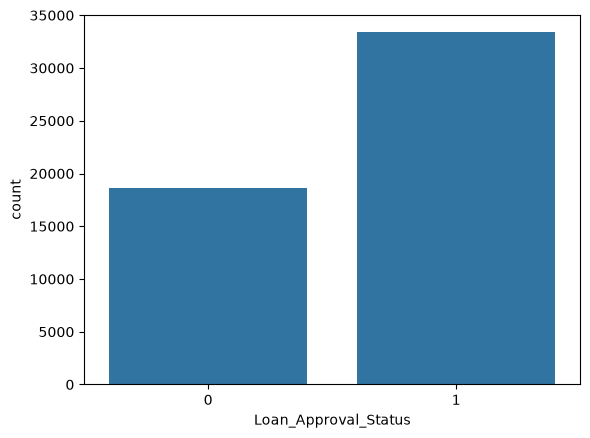

In [11]:
import seaborn as sns
sns.countplot(x="Loan_Approval_Status", data=df)

In [12]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]


In [13]:
print(x.columns.tolist())

['Applicant_ID', 'Gender', 'Age', 'Marital_Status', 'Dependents', 'Education', 'Employment_Status', 'Occupation_Type', 'Residential_Status', 'City/Town', 'Annual_Income', 'Monthly_Expenses', 'Credit_Score', 'Existing_Loans', 'Total_Existing_Loan_Amount', 'Outstanding_Debt', 'Loan_History', 'Loan_Amount_Requested', 'Loan_Term', 'Loan_Purpose', 'Interest_Rate', 'Loan_Type', 'Co-Applicant', 'Bank_Account_History', 'Transaction_Frequency', 'Default_Risk']


In [14]:
num_col = x.select_dtypes(include=['int64', 'float64']).columns.tolist()

cat_col = x.select_dtypes(include=['object', 'string', 'str']).columns.tolist()

In [15]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

In [16]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    
])

In [17]:
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_col),
        ("cat", cat_pipeline, cat_col)
    ]
)




In [19]:
pipeline_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

In [20]:
pipeline_dt = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

In [21]:
pipeline_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ))
])

In [22]:
pipeline_rf.fit(x_train, y_train)
pipeline_dt.fit(x_train, y_train)
pipeline_xgb.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [23]:
y_pred_rf = pipeline_rf.predict(x_test)
y_pred_rf

array([1, 1, 1, ..., 1, 1, 1], shape=(10400,))

In [24]:

print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("Accuracy :", accuracy_score(y_test, y_pred_rf))

Precision: 0.8576637407157326
Recall   : 0.9343828159482125
F1 Score : 0.8943810730882974
Accuracy : 0.8557692307692307


In [25]:

y_pred_dt = pipeline_dt.predict(x_test)
y_pred_dt

array([1, 0, 1, ..., 1, 1, 1], shape=(10400,))

In [26]:

print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("Accuracy :", accuracy_score(y_test, y_pred_dt))

Precision: 0.8016089860352156
Recall   : 0.7769604237163454
F1 Score : 0.7890922674635786
Accuracy : 0.7285576923076923


In [27]:

y_pred_xgb = pipeline_xgb.predict(x_test)
y_pred_xgb

array([1, 1, 1, ..., 1, 1, 1], shape=(10400,))

In [28]:

print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))

Precision: 0.8559837728194726
Recall   : 0.9312932175959983
F1 Score : 0.8920518602029313
Accuracy : 0.8526923076923076


In [29]:
from sklearn.metrics import classification_report

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

print("XGBoost")
print(classification_report(y_test, y_pred_xgb))

Random Forest
              precision    recall  f1-score   support

           0       0.85      0.71      0.77      3603
           1       0.86      0.93      0.89      6797

    accuracy                           0.86     10400
   macro avg       0.85      0.82      0.83     10400
weighted avg       0.86      0.86      0.85     10400

XGBoost
              precision    recall  f1-score   support

           0       0.84      0.70      0.77      3603
           1       0.86      0.93      0.89      6797

    accuracy                           0.85     10400
   macro avg       0.85      0.82      0.83     10400
weighted avg       0.85      0.85      0.85     10400



In [30]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    pipeline_rf,
    x_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print(scores)
print("Mean Accuracy:", scores.mean())

[0.85240385 0.84411058 0.84879808 0.85084135 0.84663462]
Mean Accuracy: 0.8485576923076922


In [31]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [10, 20, 30, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

In [32]:
random_search = RandomizedSearchCV(
    pipeline_rf,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42
)

random_search.fit(x_train, y_train)

print(random_search.best_params_)
print(random_search.best_score_)

{'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_depth': None}
0.8449894840540162


In [33]:
best_model = random_search.best_estimator_

In [34]:


joblib.dump(best_model, "loan_approval_model.pkl")

['loan_approval_model.pkl']